<a href="https://colab.research.google.com/github/brighamfrandsen/econ484/blob/master/examples/10_Stacked.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
!git clone https://github.com/brighamfrandsen/econ484.git
%cd econ484/utilities
from preamble import *
%cd ../data



fatal: destination path 'econ484' already exists and is not an empty directory.
/content/econ484/utilities
/content/econ484/data


# Model Stacking


A stacked model combines the predictions of several individual models by running a ridge regression of the outcome on the individual predictions:
$$\hat y(x_i) =\beta_0 +\beta_1 \hat y_1(x_i) + \cdots +\beta_B \hat y_B(x_i) $$

Let's first try it on some fake data:

Text(0, 0.5, 'y')

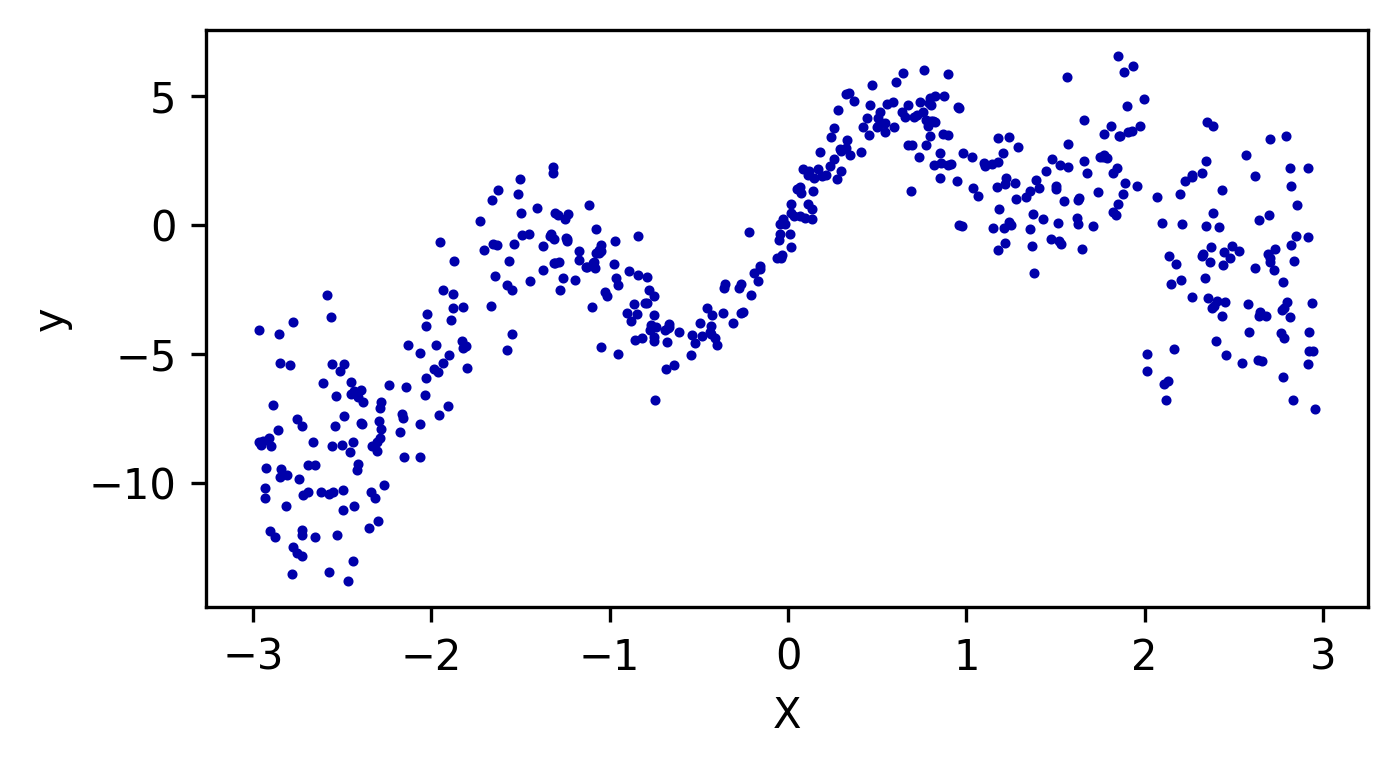

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# instantiate a random number generator:
rng = np.random.RandomState(42)

# generate some random time series data with a trend, seasonality, and a discontinuous drop:
X = rng.uniform(-3, 3, size=500)
trend = 2.4 * X
seasonal = 3.1 * np.sin(3.2 * X)
drop = 10.0 * (X > 2).astype(float)

# Add in some heteroskedasticity for good measure:
sigma = 0.75 + 0.75 * X**2

# put it all together in our y-variable:
y = trend + seasonal - drop + rng.normal(loc=0.0, scale=np.sqrt(sigma))

# put X and y in a data frame:
df = pd.DataFrame({"X": X, "y": y})
# And graph it:
plt.scatter(X,y,s=2)
plt.xlabel("X")
plt.ylabel("y")

Now let's import the packages for the individual models we want to stack:

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LassoCV, RidgeCV

# And for creating transformations of X:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split

Let's pre-process our data by creating powers and standardizing:

In [4]:
# Generate powers up to six, do not include a constant:
poly = PolynomialFeatures(degree=6,include_bias=False)
scaler = StandardScaler()
Xpoly = poly.fit_transform(df[['X']])
Xpolystd = scaler.fit_transform(Xpoly)

Now instantiate our individual estimators and put them in a list:

In [5]:
lasso = LassoCV()
gbr = GradientBoostingRegressor(max_depth=1,learning_rate=.2)
rf = RandomForestRegressor()

estimators = [
    ("Lasso", lasso),
    ("Gradient Boosting Regressor", gbr),
    ("Random Forest", rf),
]

And finally, feed them all to StackingRegressor and train!

In [6]:
stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())
stacking_regressor.fit(Xpolystd,y)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.056e+01, tolerance: 9.874e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.010e+01, tolerance: 7.502e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+01, tolerance: 8.219e

StackingRegressor(estimators=[('Lasso', LassoCV()),
                              ('Gradient Boosting Regressor',
                               GradientBoostingRegressor(learning_rate=0.2,
                                                         max_depth=1)),
                              ('Random Forest', RandomForestRegressor())],
                  final_estimator=RidgeCV())

Let's visualize how it did:

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Stacked Prediction')

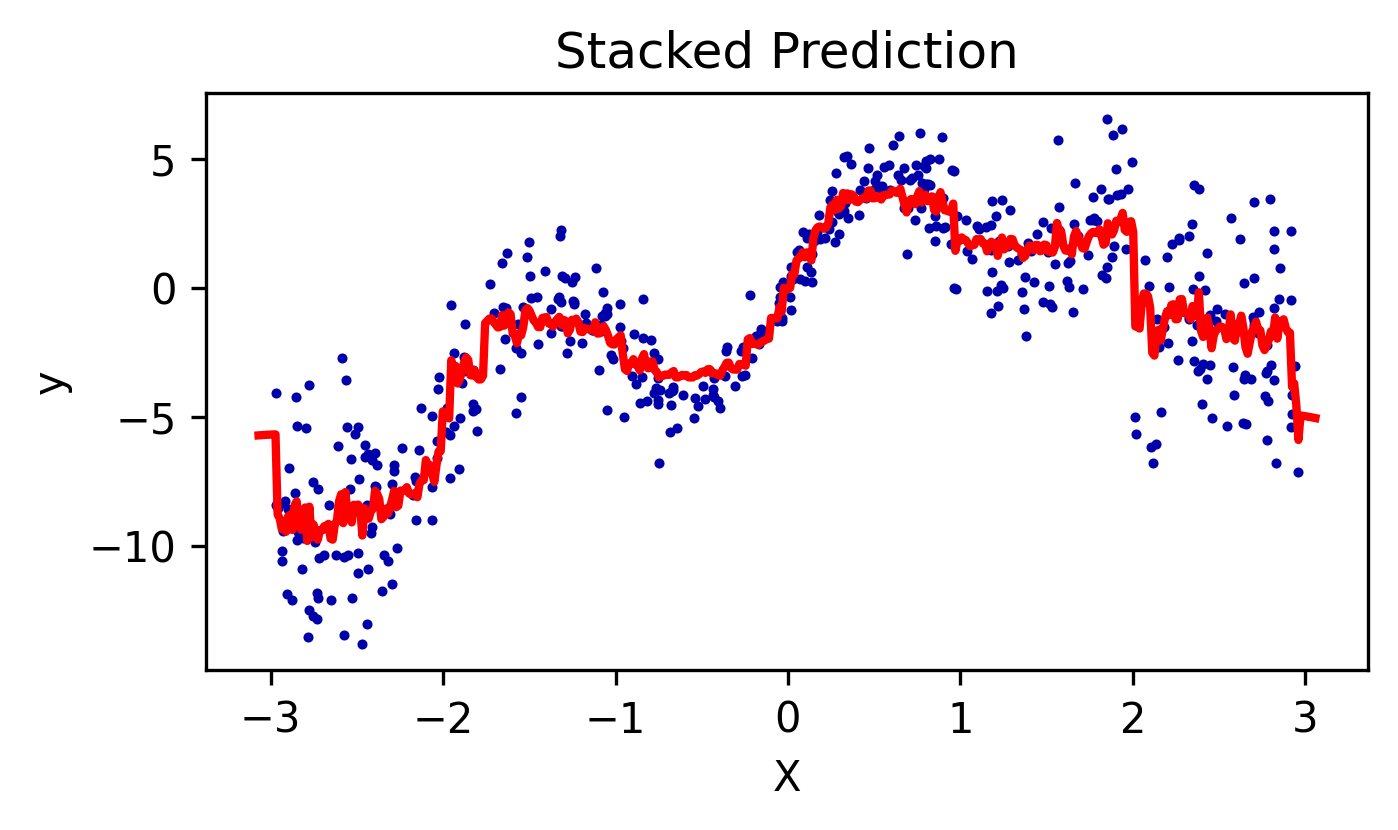

In [7]:
# create a smaller number of points at which to form predictions:
x_plot = np.linspace(X.min() - 0.1, X.max() + 0.1, 500).reshape(-1, 1)
# do the same transformations on this smaller set:
x_plot_transformed = scaler.transform(poly.transform(x_plot))
# and get predictions
pred_plot = stacking_regressor.predict(x_plot_transformed)

# and graph:
plt.scatter(X,y,s=2)
plt.plot(x_plot,pred_plot,c='red')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Stacked Prediction")

Now let's try stacking on the breast cancer data:

In [8]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

tree = DecisionTreeClassifier()
gbt = GradientBoostingClassifier(max_depth=1,learning_rate=.2)

estimators = [
    ("DecisionTree", tree),
    ("Gradient Boosting Classifier", gbt)
]
stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_classifier.fit(X_train,y_train)

print("Accuracy on training set: {:.3f}".format(stacking_classifier.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(stacking_classifier.score(X_test, y_test)))



Accuracy on training set: 0.995
Accuracy on test set: 0.937


On your own: train a stacking classifier, but with random forest and gradient boosted tree, instead of a decision tree and gradient boosted tree. Do you do any better?